<a href="https://colab.research.google.com/github/rgulamali/AIMAppForAPI/blob/master/ReadCSVCalMA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

After uploading, you can read the file into a pandas DataFrame. Remember to replace `your_file_name.csv` with the exact name of the file you uploaded.

In [16]:
import yfinance as yf
import plotly.graph_objs as go
import pandas as pd # Added pandas import

stock_name = "SPY"
#stock_name = "AAPL"

# Define the custom start date for data retrieval
start_date = "2020-11-02"

# Changed interval to '1d' for historical data beyond 60 days
delta_t = '1d'

df = yf.download(
    tickers=stock_name,
    start=start_date, # Use the custom start date
    # Removed 'end' parameter to fetch data up to the current date
    interval=delta_t
)

# Flatten multi-level column names if they exist from yfinance download
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.droplevel(1) # Drop the ticker symbol level
    df.columns.name = None # Remove the name of the remaining level (e.g., 'Price')

# Display the first few rows to confirm structure
display(df.head())

/tmp/ipykernel_5342/2805864693.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(
[*********************100%***********************]  1 of 1 completed


,Close,High,Low,Open,Volume
Date,,,,,
2020-11-02,306.089630,308.091887,303.345742,306.089630,86068300
2020-11-03,311.493927,313.551829,306.173057,309.324791,93294200
2020-11-04,318.455597,322.534315,314.794004,315.971262,126959700
2020-11-05,324.666382,326.474009,323.387141,323.739399,82039700
2020-11-06,324.592224,325.843656,322.265489,324.379008,74973000


First, let's ensure the 'Date' column is in datetime format and sort the DataFrame by date, which is crucial for accurate moving average calculations.

In [17]:
df = df.assign(
    ma_50=lambda d: d["Close"].rolling(window=50, min_periods=50).mean(),
    ma_200=lambda d: d["Close"].rolling(window=200, min_periods=200).mean(),
    gc=lambda d: ((d["ma_50"] > d["ma_200"]) & (d["ma_50"].shift(1) <= d["ma_200"].shift(1))).astype(int)
)

df[df["gc"] == 1]

,Close,High,Low,Open,Volume,ma_50,ma_200,gc
Date,,,,,,,,
2023-01-26,388.012482,388.175465,383.487665,386.459478,72287400,376.070803,375.944885,1
2025-06-27,609.738037,611.205630,605.692397,607.725143,86258400,573.074659,572.933100,1


Let's first define the 'gc' (golden cross) column in your DataFrame. A golden cross occurs when the 50-day moving average crosses above the 200-day moving average.

First, let's ensure the 'Date' column is in datetime format and sort the DataFrame by date, which is crucial for accurate moving average calculations. Then, we will explicitly add the `MA_50`, `MA_200`, and `gc` (golden cross) columns to your `df` DataFrame.

In [18]:
import pandas as pd

# Convert the DataFrame's index (which contains the datetime information) to a 'Date' column
# and reset the index to create a default integer index.
df = df.reset_index(names=['Date'])

# Ensure the 'Date' column is in datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Sort by Date to ensure correct chronological order for moving average calculations
df = df.sort_values(by='Date').reset_index(drop=True)

# Calculate 50-day moving average
df['MA_50'] = df['Close'].rolling(window=50, min_periods=50).mean()

# Calculate 200-day moving average
df['MA_200'] = df['Close'].rolling(window=200, min_periods=200).mean()

# Golden cross: 50 MA crosses above 200 MA
df['gc'] = (
    (df['MA_50'].shift(1) <= df['MA_200'].shift(1)) &
    (df['MA_50'] > df['MA_200'])
).astype(int)

display(df[['Date', 'Close', 'MA_50', 'MA_200', 'gc']].tail(20))
#number of rows in df
len(df)

,Date,Close,MA_50,MA_200,gc
1332,2026-02-24,685.477905,685.335020,648.118150,0
1333,2026-02-25,691.262207,685.454902,648.781182,0
1334,2026-02-26,687.422607,685.645354,649.428575,0
1335,2026-02-27,684.121643,685.790270,649.967270,0
1336,2026-03-02,684.510620,685.979954,650.488878,0
1337,2026-03-03,678.477112,686.197522,650.976612,0
1338,2026-03-04,683.263977,686.410002,651.474092,0
1339,2026-03-05,679.454407,686.424363,651.934036,0
1340,2026-03-06,670.548706,686.176040,652.346238,0
1341,2026-03-09,676.422729,685.982769,652.797698,0


1352

Now that the columns are properly added to the `df` DataFrame, let's visualize the 'Close' price, 50-day Moving Average, 200-day Moving Average, and highlight the golden cross points.

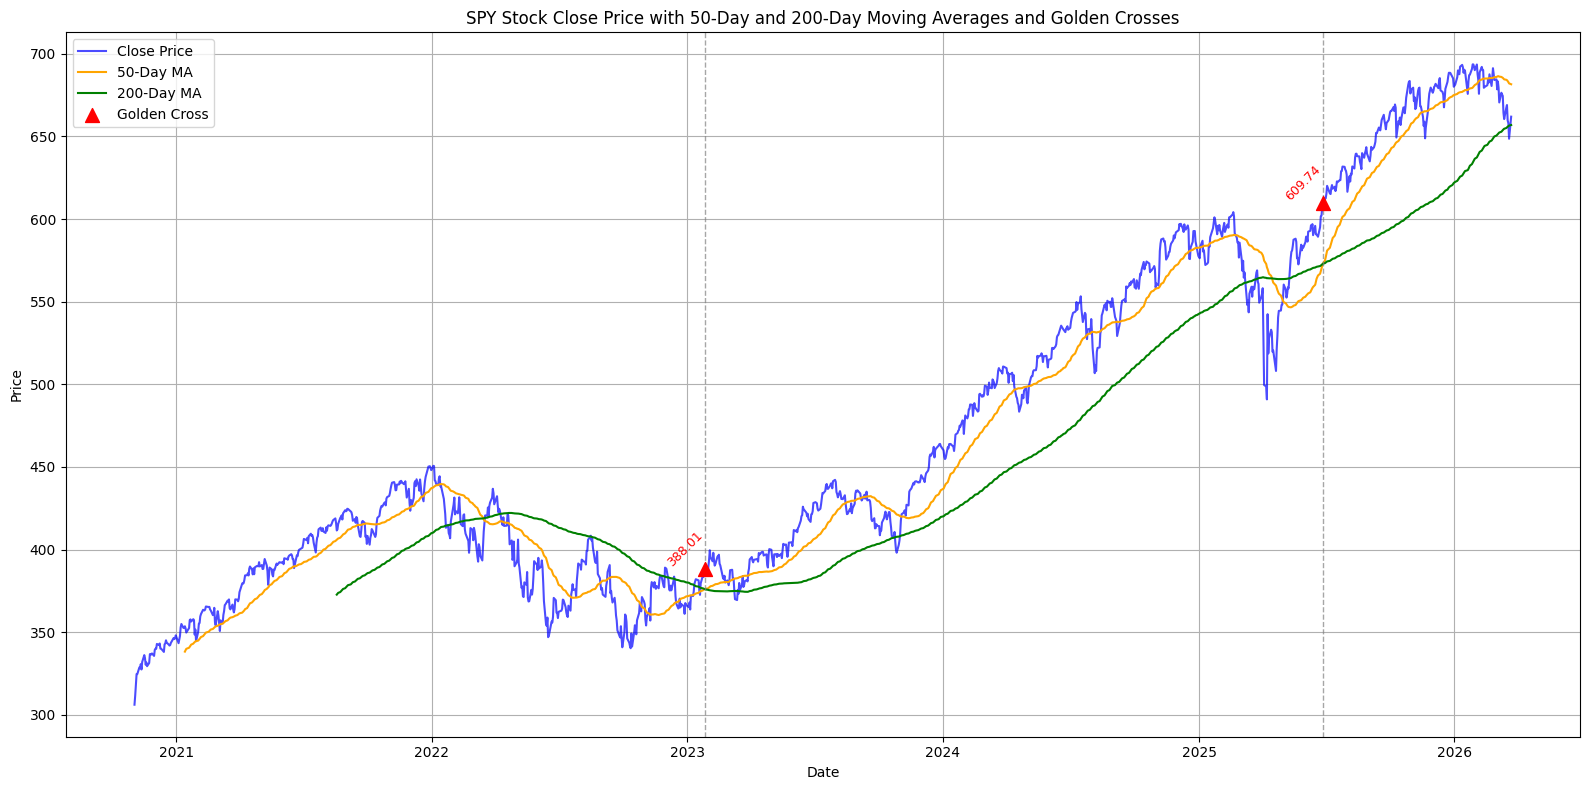

In [19]:
#display the graph
import matplotlib.pyplot as plt
import seaborn as sns

# Set the figure size for better readability of the plot
plt.figure(figsize=(16, 8))

# Plot the 'Close Price' as a blue line with some transparency
sns.lineplot(x='Date', y='Close', data=df, label='Close Price', color='blue', alpha=0.7)
# Plot the 50-day Moving Average as an orange line
sns.lineplot(x='Date', y='MA_50', data=df, label='50-Day MA', color='orange')
# Plot the 200-day Moving Average as a green line
sns.lineplot(x='Date', y='MA_200', data=df, label='200-Day MA', color='green')

# Identify golden cross points where 'gc' column is 1
golden_cross_points = df[df['gc'] == 1]
# Mark these golden cross points on the plot using red upward-pointing triangles
plt.scatter(golden_cross_points['Date'], golden_cross_points['Close'],
            color='red', marker='^', s=100, zorder=5, label='Golden Cross')

# Loop through each golden cross point to add vertical lines and text annotations
for index, row in golden_cross_points.iterrows():
    # Add a dashed gray vertical line at the date of the golden cross
    plt.axvline(x=row['Date'], color='gray', linestyle='--', linewidth=1, alpha=0.7)
    # Add text annotation for the 'Close' price at the golden cross point
    plt.text(row['Date'], row['Close'], f'{row['Close']:.2f}',
             verticalalignment='bottom', horizontalalignment='right',
             color='red', fontsize=9, rotation=45)

# Set the title of the plot
plt.title(f'{stock_name} Stock Close Price with 50-Day and 200-Day Moving Averages and Golden Crosses')
# Set the x-axis label
plt.xlabel('Date')
# Set the y-axis label
plt.ylabel('Price')
# Display the legend to identify each line and marker
plt.legend()
# Add a grid to the plot for better readability
plt.grid(True)
# Adjust plot layout to prevent labels from overlapping
plt.tight_layout()
# Show the plot
plt.show()